# Overfeeding

In [73]:
import datetime
import pingouin as pg
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
sns.set_theme(context='talk', style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = 10, 7
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['figure.autolayout'] = 'true'
plt.rcParams['figure.frameon'] = 'false'
plt.rcParams['axes.spines.left'] = 'false'
plt.rcParams['axes.spines.right'] = 'false'
plt.rcParams['axes.spines.top'] = 'false'
plt.rcParams['legend.fancybox'] = 'false'
plt.rcParams['axes.spines.bottom'] = 'false'
plt.rcParams['font.size'] = 20
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
# для графиков, где надо много цветов, юзайте воть:
sns.set_palette(sns.color_palette('deep'))
# а по дефолту воть:
sns.set_palette(sns.color_palette('BuGn_r', n_colors=10)[2::3])
pd.set_option('display.max_columns', 60)

monthly_feeding = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Feeding')
herd_metrics = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Herd maintenance').replace('-', np.nan)
production_indicators = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Dairy indicators').replace('-', np.nan)

herd_metrics["year_month"] = herd_metrics["date"].dt.to_period('M').astype(str)

fad = pd.read_csv("datasets/FeedingAndDetails_clear.csv", index_col=0)
fad["Date"] = pd.to_datetime(fad["Date"])
fad["year_month"] = fad["Date"].dt.to_period('M').astype(str)
fad = fad.rename(columns={"FarmName": "farm_name"})

In [74]:
union = pd.merge(production_indicators, herd_metrics, on=['date', 'farm_name', 'prod_farm_name', 'region'], how='inner', suffixes=["_farm", "_herd"])
union['date'] = pd.to_datetime(union['date'])
union = union.drop("farm_type_farm", axis=1)
union.loc[309]["farm_type_herd"] = "ЖК"
union = union.rename(columns={"farm_type_herd": "farm_type"})


In [75]:
df = fad.copy()

grouped = df.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName", "year_month"]
)["PhysicalWeight_kg"].sum().reset_index()

dff = df.groupby(["Date", "farm_name", "PhysiologicalGroupName", "SectionID"]).agg(
    UniqueHeads=("PhysiologicalGroupHeadCount", "max")
)

appetites = dff.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName"]
).agg({
    "UniqueHeads": "sum"
}).reset_index().rename(columns={"UniqueHeads": "CowCount"})

date_phy_feeding = pd.merge(
    grouped,
    appetites,
    on=["Date", "farm_name", "PhysiologicalGroupName"],
    how="left"
)
date_phy_feeding["WeightPerCow"] = date_phy_feeding["PhysicalWeight_kg"] / date_phy_feeding["CowCount"]
date_phy_feeding

,Date,farm_name,PhysiologicalGroupName,year_month,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01-01,ЖК Добрино,Д0 (Новотельные),2022-01,6076.165,136,44.677684
1,2022-01-01,ЖК Добрино,Д1,2022-01,143544.434,2710,52.968426
2,2022-01-01,ЖК Добрино,Д2,2022-01,16102.000,345,46.672464
3,2022-01-01,ЖК Добрино,Нетели,2022-01,29691.786,1245,23.848824
4,2022-01-01,ЖК Добрино,С1,2022-01,5237.236,172,30.449047
...,...,...,...,...,...,...,...
520366,2025-10-22,РМ Поляна,Т2 (6-8 мес.),2025-10,2773.000,175,15.845714
520367,2025-10-22,РМ Поляна,Т3 (9-12 мес.),2025-10,3196.000,158,20.227848
520368,2025-10-22,РМ Торопово,Нетели,2025-10,26393.897,988,26.714471
520369,2025-10-22,РМ Торопово,Т3 (9-12 мес.),2025-10,2932.291,150,19.548607


In [76]:
fad

,FeedingTaskID,Date,farm_name,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,IngredientID,PhysicalWeight_kg,ingredient_name,ingredient_group,year_month
0,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,125.0,150.259,солома покупная,Объёмные корма,2022-01
1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,773.0,880.444,люцерна сенаж,Объёмные корма,2022-01
2,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,72.0,542.257,комбикорм 10 группы,Комбикорма и стартеры,2022-01
3,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,82.0,991.793,кукуруза сухая,Энергетические и крахмалистые корма,2022-01
4,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,129.0,156.054,шрот подсолнечный,Белковые корма,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16411360,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,119.0,120.643,солома (общ.),Объёмные корма,2025-10
16411361,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,335.0,549.169,люцерна сенаж,Объёмные корма,2025-10
16411362,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,331.0,36.676,жом свекловичный сухой,Комбикорма и стартеры,2025-10
16411363,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,143.0,10.049,премикс молодняк 6-24,Премиксы,2025-10


In [77]:
monthly_feeding = date_phy_feeding.groupby(
    ['year_month', 'farm_name', 'PhysiologicalGroupName']
).agg({
    'PhysicalWeight_kg': 'sum',
    'CowCount': 'sum',
    'WeightPerCow': 'mean'
}).reset_index()
monthly_feeding

,year_month,farm_name,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01,ЖК Добрино,Д0 (Новотельные),127449.683,3185,39.929478
1,2022-01,ЖК Добрино,Д1,4798144.919,85892,55.881165
2,2022-01,ЖК Добрино,Д2,810123.966,18490,44.579594
3,2022-01,ЖК Добрино,Нетели,1093767.137,42374,25.797685
4,2022-01,ЖК Добрино,С1,148710.380,4695,31.675238
...,...,...,...,...,...,...
17904,2025-10,ЭФ Родня,Т0 (0-2 мес.),7692.108,1282,6.000080
17905,2025-10,ЭФ Родня,Т1 (3-5 мес.),13328.941,941,14.216873
17906,2025-10,ЭФ Родня,Т2 (6-8 мес.),19288.227,1054,18.240005
17907,2025-10,ЭФ Родня,Т3 (9-12 мес.),0.000,0,NaN


In [78]:
def rename_shit(dff):
    """Renames bad PhysiologicalGroupNames"""
    mapping = {'Д0 (Новотельные)': 'Д0', 'Н Нетели': 'Нетели', 'Д3 (Предзапуск)': 'Д3', 'D3': 'Д3', 
               'Нетели 1  группа': 'Нетели','Сух-2': "С2", 'Д-3': 'Д3', 'сух 1': 'С1', 'сух 2': 'С2', 'С1 нетели': 'С1', 
               'С2 нетели': 'С2', 'Н НЕТЕЛИ': 'Нетели', 'Сух 2 Нетели': 'С2', 'С2 Нетели': 'С2'}

    dff["PhysiologicalGroupName"] = dff["PhysiologicalGroupName"].replace(mapping)
    return dff

monthly_feeding = rename_shit(monthly_feeding)
monthly_feeding["PhysiologicalGroupName"].unique()

array(['Д0', 'Д1', 'Д2', 'Нетели', 'С1', 'С2', 'Т0 (0-2 мес.)',
       'Т1 (3-5 мес.)', 'Т2 (6-8 мес.)', 'Т3 (9-12 мес.)', 'Т4 (>1 года)',
       'Б0 (0-2 мес.)', 'Д3', 'Т3 9-12', 'Т0', 'Б3 (9-12 мес.)',
       'Т0 (3-5 мес.)', 'МГ Т3', 'Т2', 'Т2 6-8', 'Т4', 'Т3',
       'Б2 (6-8 мес.)', 'Т4 13-20', 'Б1 (3-5 мес.)', 'Телята СВОД Навесы',
       'МГ Т2', 'МП Коровы', 'Т3 (9-12 мес)', 'МП Нетели',
       'МП БП (бык-производитель)', 'Б4 (>1 года)',
       'МП Б1 (6-12 мес. откорм)', 'МП БР2 (>1 года рем.)',
       'МП Т2 (>1 года откорм)', 'МП БР1 (6-12 мес. рем.)',
       'МП Т0 (0-6 мес.)', 'МП ТР1 (6-12 мес. рем.)', 'Телята домики',
       'МП ТР2 (>1 года рем.)', 'МП Б0 (0-6 мес.)',
       'МП Б2 (>1 года откорм)', 'быки племенные', 'Лошади',
       'Т0 (0-2 мес)', 'Коровы'], dtype=object)

<Axes: xlabel='WeightPerCow', ylabel='Count'>

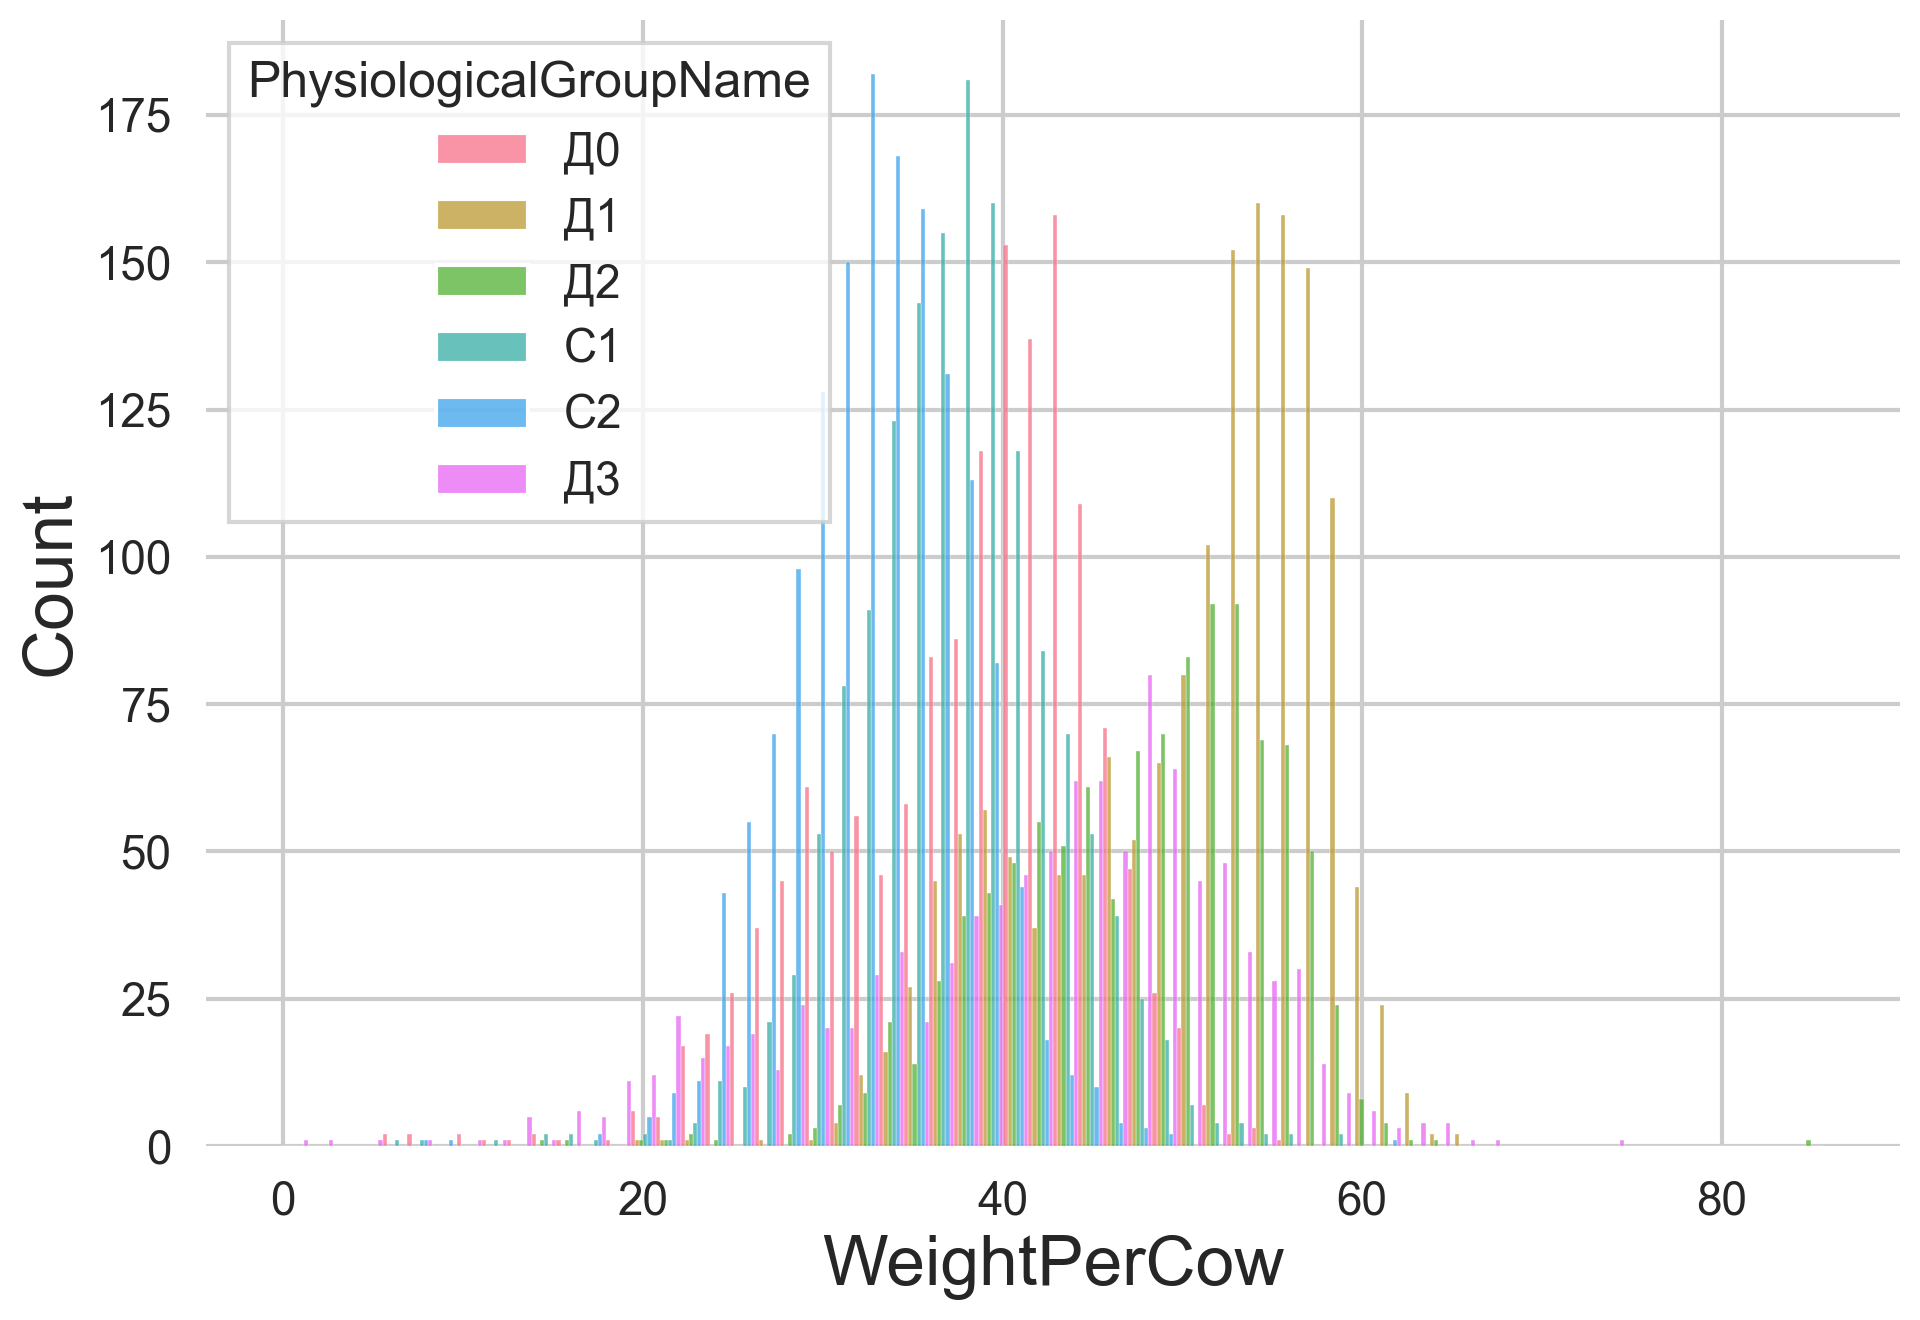

In [79]:
sns.histplot(monthly_feeding[monthly_feeding["PhysiologicalGroupName"].isin(['Д0', 'Д1', 'Д2', 'Д3', 'С1', 'С2'])], x="WeightPerCow", hue="PhysiologicalGroupName", multiple="dodge")

In [80]:
df = pd.merge(herd_metrics, monthly_feeding, on=["farm_name", "year_month"], how="inner")
df

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д0,127449.683,3185,39.929478
1,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д1,4798144.919,85892,55.881165
2,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д2,810123.966,18490,44.579594
3,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Нетели,1093767.137,42374,25.797685
4,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,С1,148710.380,4695,31.675238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15102,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д1,3895939.988,90441,43.065674
15103,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д2,446308.259,7865,57.088245
15104,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Нетели,327875.922,10857,30.362285
15105,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,С1,142383.378,3742,37.884068


<Axes: xlabel='date', ylabel='cow_metrit'>

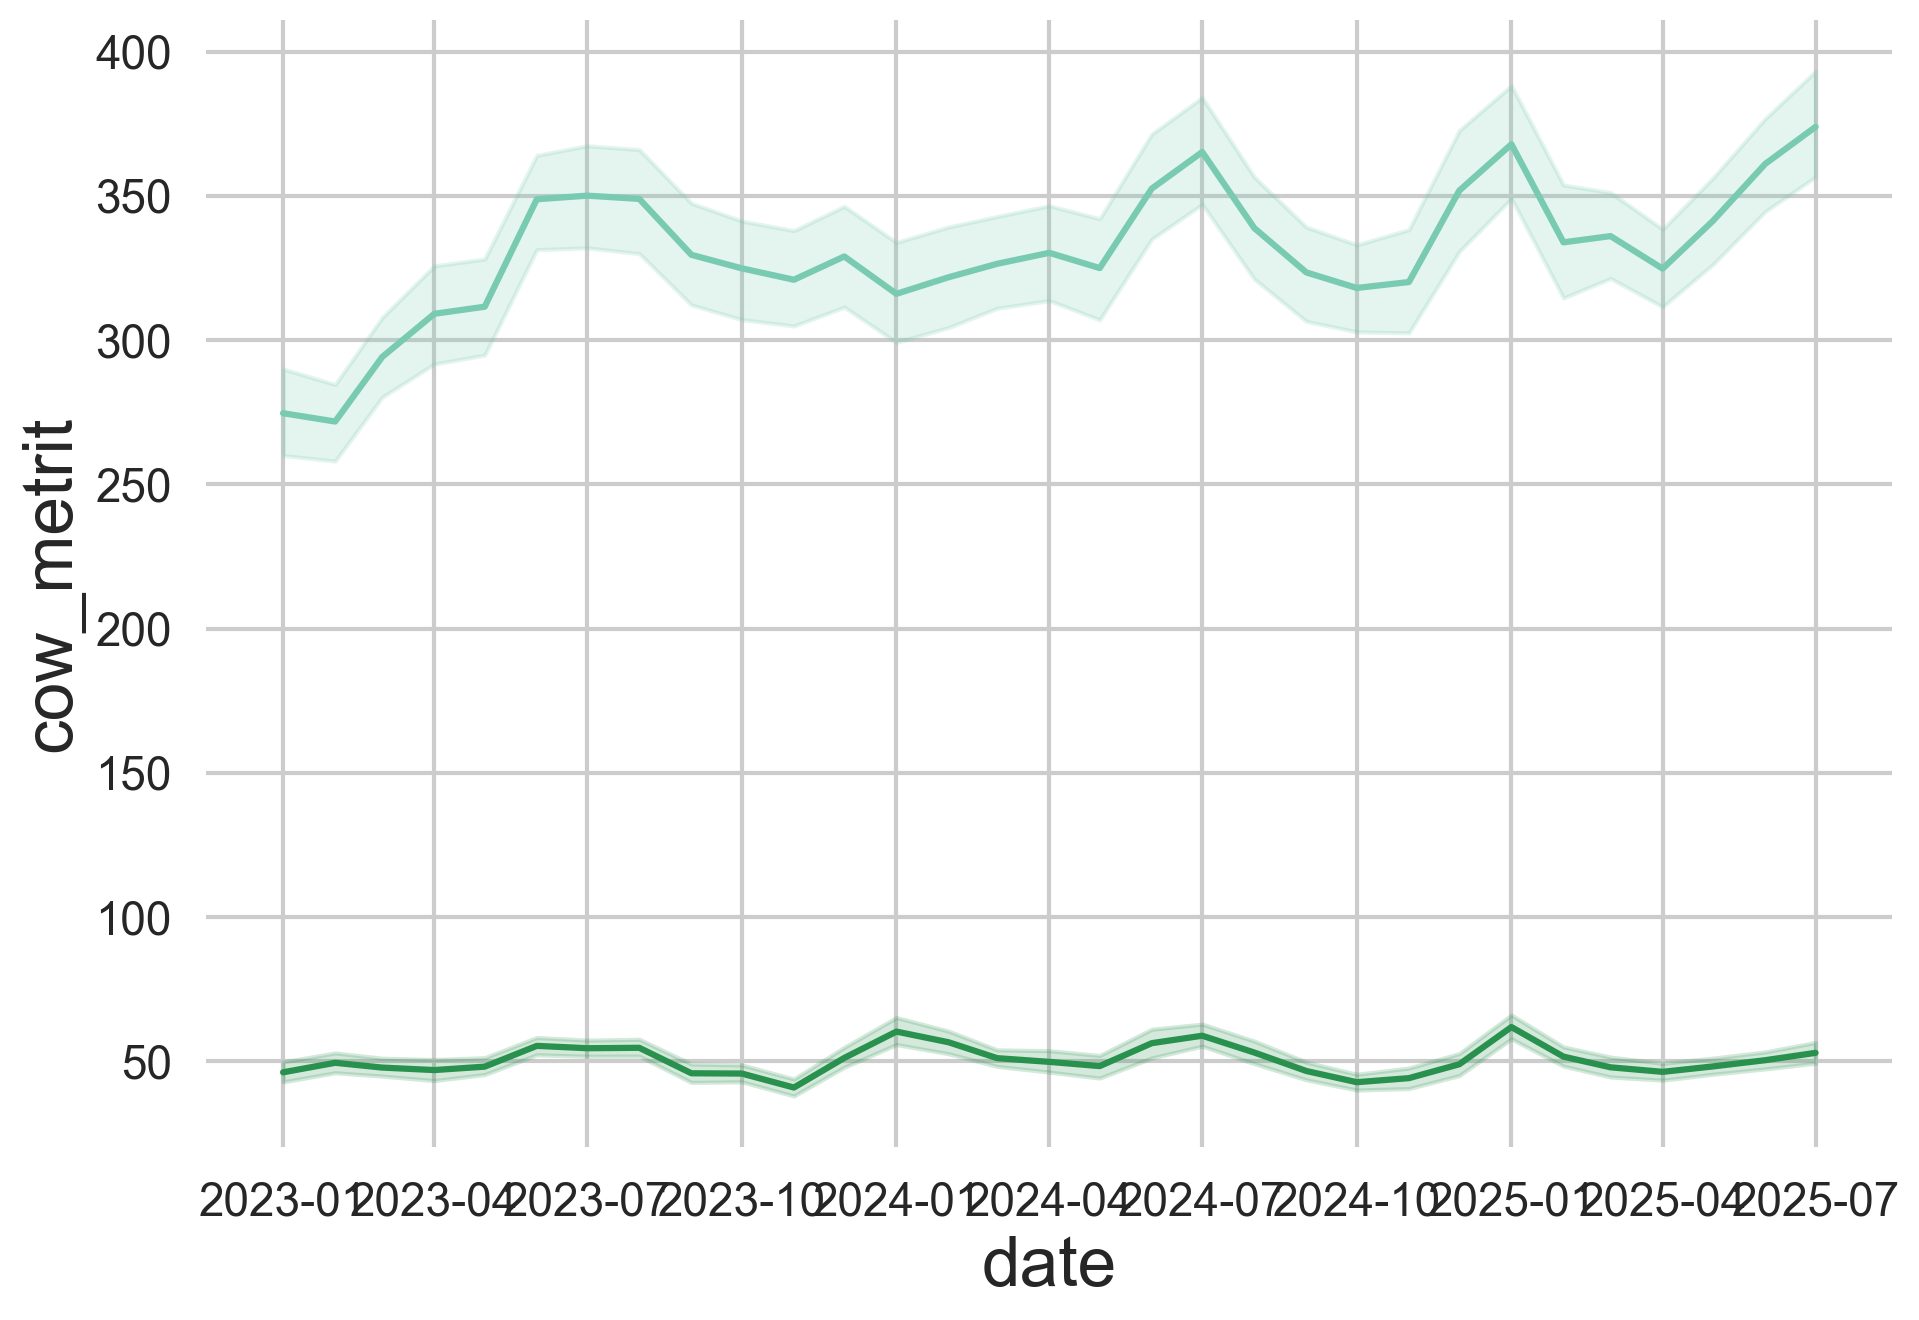

In [81]:
sns.lineplot(df, x="date", y="cow_metrit")
sns.lineplot(df, x="date", y="calves")

In [82]:
df["metrit_rate"] = df["cow_metrit"] / df["calves"]
df

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow,metrit_rate
0,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д0,127449.683,3185,39.929478,NaN
1,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д1,4798144.919,85892,55.881165,NaN
2,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д2,810123.966,18490,44.579594,NaN
3,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Нетели,1093767.137,42374,25.797685,NaN
4,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,С1,148710.380,4695,31.675238,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15102,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д1,3895939.988,90441,43.065674,0.206128
15103,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Д2,446308.259,7865,57.088245,0.206128
15104,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,Нетели,327875.922,10857,30.362285,0.206128
15105,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.4,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,С1,142383.378,3742,37.884068,0.206128


In [83]:
df[df["metrit_rate"].isna()]

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow,metrit_rate
0,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д0,127449.683,3185,39.929478,NaN
1,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д1,4798144.919,85892,55.881165,NaN
2,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Д2,810123.966,18490,44.579594,NaN
3,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,Нетели,1093767.137,42374,25.797685,NaN
4,2022-01-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2800.0,104.964286,2939.0,2748.0,191.0,94.0,NaN,NaN,NaN,NaN,85.0,12.0,51.0,59.0,31,NaN,NaN,NaN,2022-01,С1,148710.380,4695,31.675238,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15084,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т0 (0-2 мес.),455036.049,53514,8.504899,NaN
15085,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т1 (3-5 мес.),384205.805,71018,5.413205,NaN
15086,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т2 (6-8 мес.),604739.798,58796,10.304948,NaN
15087,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,Т3 (9-12 мес.),1361325.481,71075,19.164864,NaN


In [84]:
import numpy as np

dfc = fad[fad["PhysiologicalGroupName"].isin(["С1", "С2"])]

dfr = dfc.groupby(["farm_name", "year_month"])["SectionID"].count()
dfr

farm_name    year_month
ЖК Авангард  2023-03        34
             2023-04       528
             2023-05       536
             2023-06       534
             2023-07       615
                          ... 
ЭФ Родня     2025-06        65
             2025-07       112
             2025-08       124
             2025-09       116
             2025-10        60
Name: SectionID, Length: 1524, dtype: int64

In [85]:
dfd = dfc.groupby(["farm_name", "year_month"])["SectionID"].nunique().reset_index()
dfd[dfd["SectionID"] > 1]


,farm_name,year_month,SectionID
0,ЖК Авангард,2023-03,2
1,ЖК Авангард,2023-04,2
2,ЖК Авангард,2023-05,2
3,ЖК Авангард,2023-06,2
4,ЖК Авангард,2023-07,2
...,...,...,...
1499,МТФ Щучье,2025-06,6
1500,МТФ Щучье,2025-07,6
1501,МТФ Щучье,2025-08,4
1502,МТФ Щучье,2025-09,5


<Axes: xlabel='WeightPerCow', ylabel='Count'>

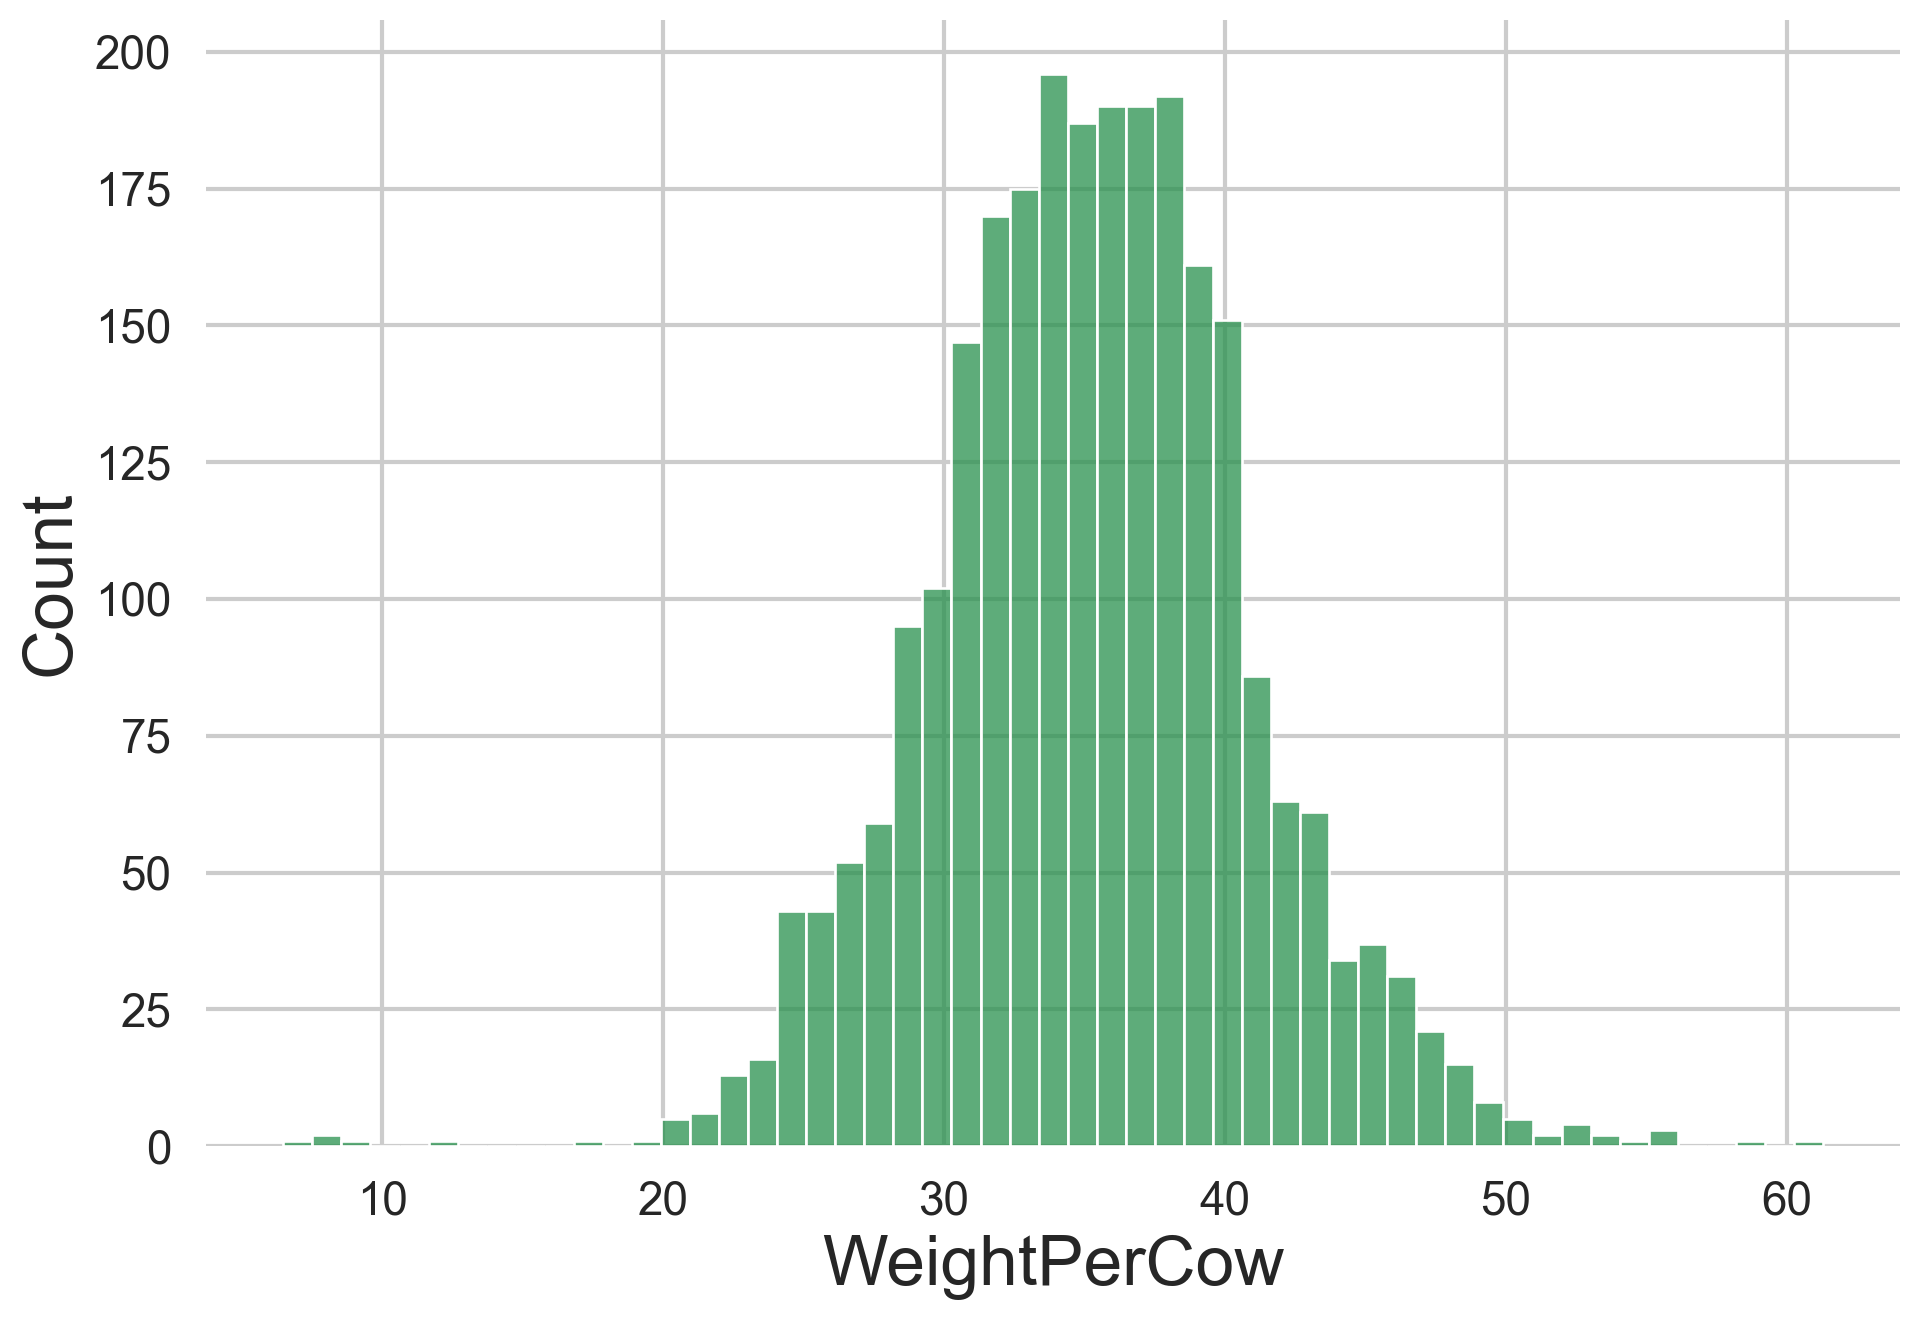

In [86]:
sns.histplot(df[df["PhysiologicalGroupName"].isin(["С1", "С2"])], x="WeightPerCow")

In [87]:
group_c = df[df["PhysiologicalGroupName"].isin(["С1", "С2"])]
group_c = group_c[(~group_c["metrit_rate"].isna()) & (group_c["calves"] != 0)]
group_c

,date,region,prod_farm_name,farm_type,farm_name,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow,metrit_rate
2260,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2900.0,100.448276,2913.0,2611.0,302.0,96.0,31.49,35.1,4.1,3.6,157.6,7.5,45.0,37.0,143,298.0,60.0,6.3,2023-01,С1,187769.472,4522,41.841824,0.201342
2261,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2900.0,100.448276,2913.0,2611.0,302.0,96.0,31.49,35.1,4.1,3.6,157.6,7.5,45.0,37.0,143,298.0,60.0,6.3,2023-01,С2,121583.091,3363,36.167541,0.201342
2271,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Верхний Икорец,2900.0,99.172414,2876.0,2534.0,342.0,98.0,31.87,35.2,4.0,3.6,201.0,26.0,43.0,56.0,40,333.0,67.0,6.0,2023-01,С1,187950.669,4896,38.330926,0.201201
2272,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Верхний Икорец,2900.0,99.172414,2876.0,2534.0,342.0,98.0,31.87,35.2,4.0,3.6,201.0,26.0,43.0,56.0,40,333.0,67.0,6.0,2023-01,С2,175654.525,5625,31.253963,0.201201
2280,2023-01-01,Воронеж,ЭНА Восток,ЖК,ЖК Петропавловка,2900.0,99.000000,2863.0,2572.0,291.0,99.0,32.44,34.2,3.8,3.4,152.0,13.0,58.0,22.0,56,237.0,24.0,6.4,2023-01,С1,192534.116,4902,39.536654,0.101266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15080,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК,ЖК Пеньково,4700.0,99.000000,4666.0,4172.0,494.0,95.0,30.11,31.8,3.9,3.4,114.0,46.0,189.0,305.0,75,843.0,123.0,6.3,2025-07,С2,538388.017,17993,30.073129,0.145907
15094,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК,ЖК Огнева Заимка,3550.0,100.000000,3544.0,3141.0,403.0,94.0,34.95,36.0,3.8,3.3,91.0,38.0,115.0,124.0,47,514.0,131.0,6.5,2025-07,С1,267597.469,6273,42.656333,0.254864
15095,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК,ЖК Огнева Заимка,3550.0,100.000000,3544.0,3141.0,403.0,94.0,34.95,36.0,3.8,3.3,91.0,38.0,115.0,124.0,47,514.0,131.0,6.5,2025-07,С2,282934.353,6615,42.776545,0.254864
15105,2025-07-01,Сибирь,ЭН Алтай,ЖК,ЖК Курочкино,3550.0,97.000000,3429.0,3189.0,240.0,98.0,36.40,37.3,3.7,3.4,75.0,30.0,76.0,157.0,69,359.0,74.0,6.4,2025-07,С1,142383.378,3742,37.884068,0.206128


In [88]:
group_c['overfed'] = group_c['WeightPerCow'] > 40
group_c = group_c[group_c["metrit_rate"] < 4]

<Axes: xlabel='overfed', ylabel='metrit_rate'>

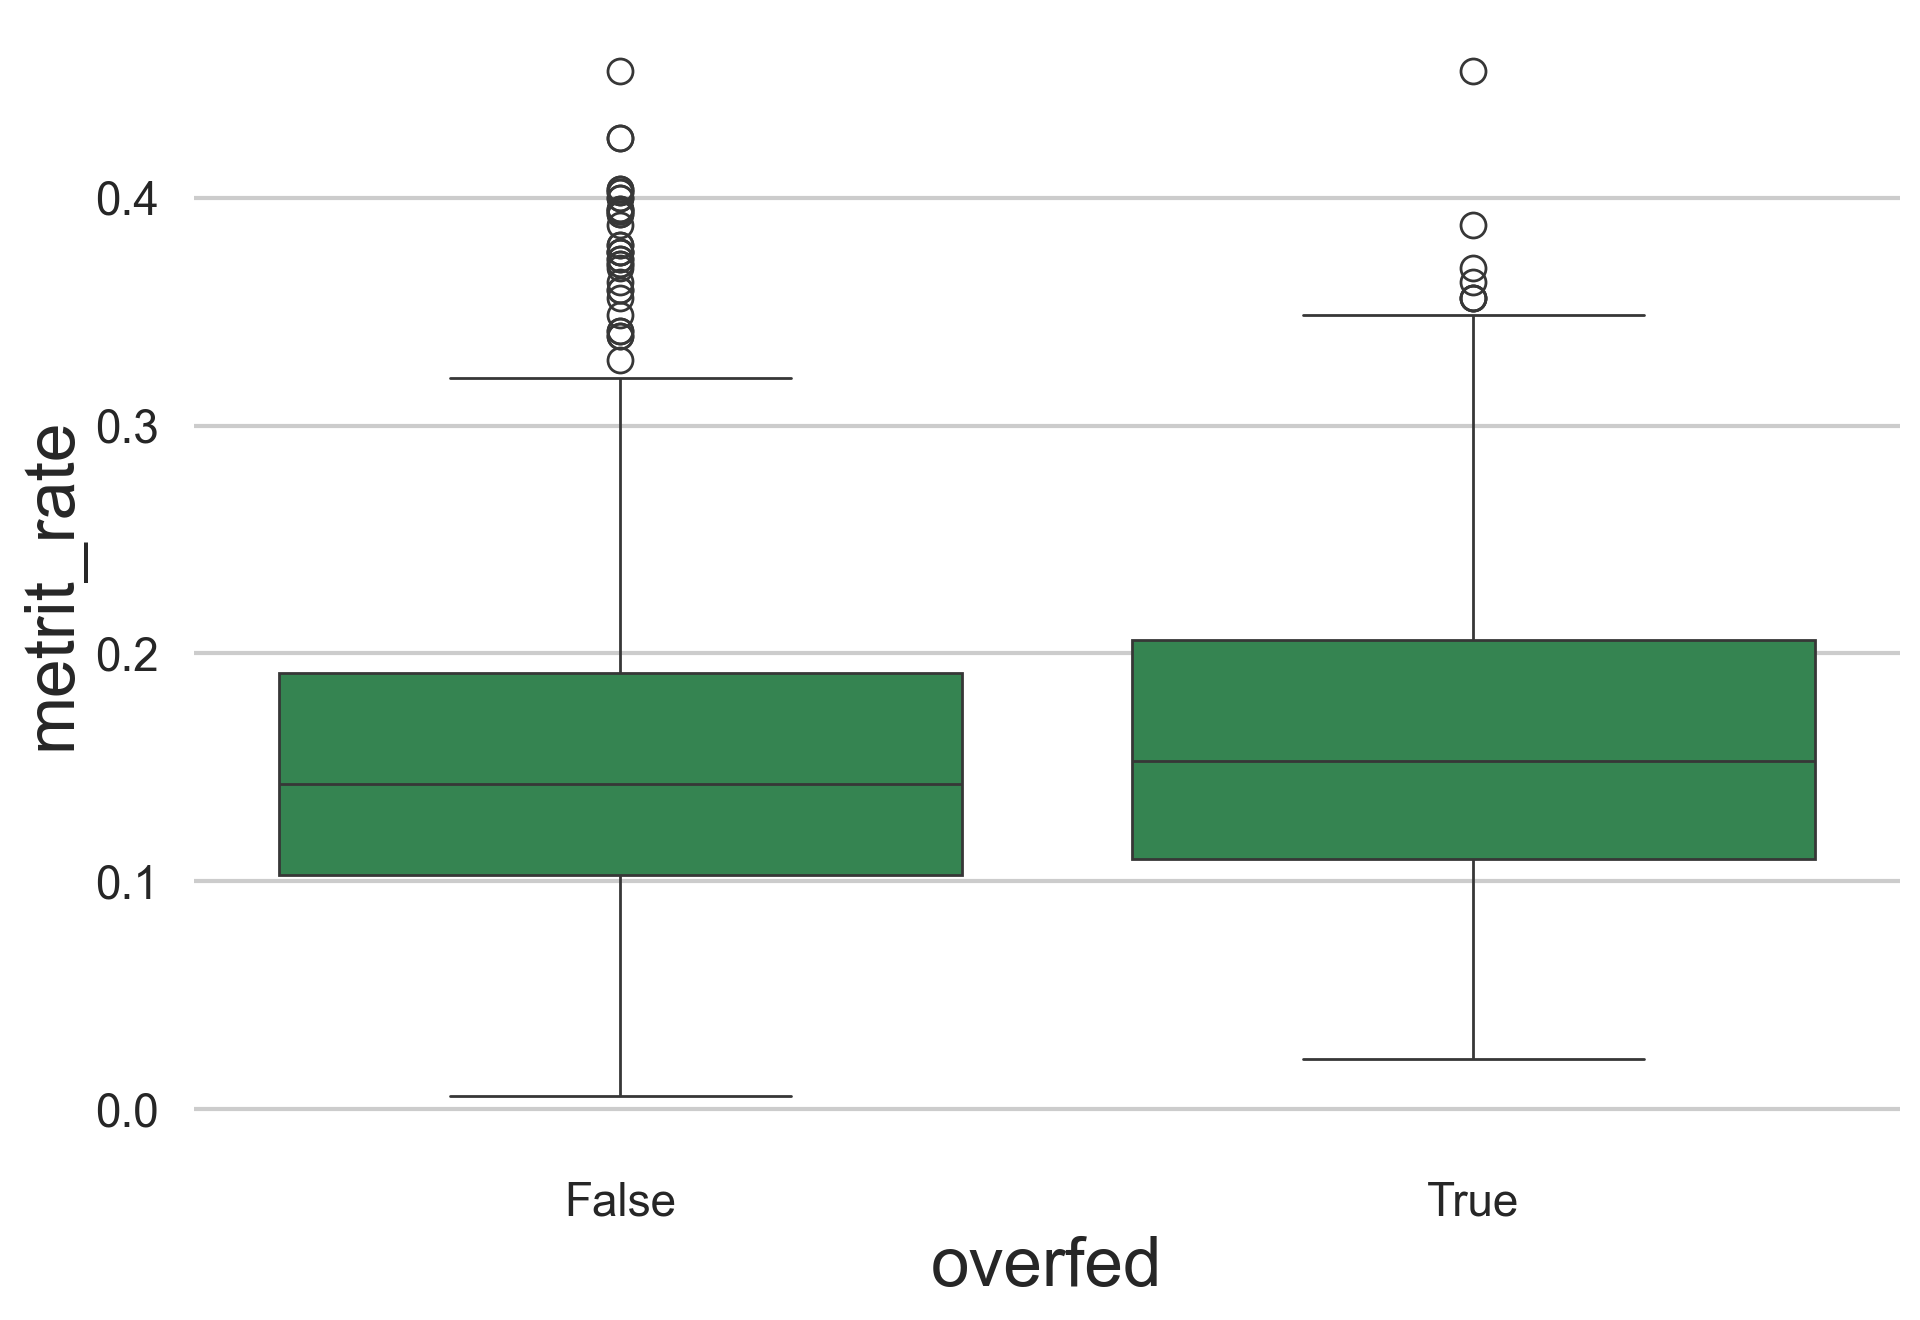

In [89]:
sns.boxplot(group_c, x="overfed", y="metrit_rate")

In [90]:
pg.ttest(group_c[group_c["overfed"] == 0]["metrit_rate"], group_c[group_c["overfed"] == 1]["metrit_rate"], alternative="less")

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.037334,630.064508,less,0.001243,"[-inf, -0.01]",0.164838,11.628,0.915112


In [91]:
monthly_feeding

,year_month,farm_name,PhysiologicalGroupName,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01,ЖК Добрино,Д0,127449.683,3185,39.929478
1,2022-01,ЖК Добрино,Д1,4798144.919,85892,55.881165
2,2022-01,ЖК Добрино,Д2,810123.966,18490,44.579594
3,2022-01,ЖК Добрино,Нетели,1093767.137,42374,25.797685
4,2022-01,ЖК Добрино,С1,148710.380,4695,31.675238
...,...,...,...,...,...,...
17904,2025-10,ЭФ Родня,Т0 (0-2 мес.),7692.108,1282,6.000080
17905,2025-10,ЭФ Родня,Т1 (3-5 мес.),13328.941,941,14.216873
17906,2025-10,ЭФ Родня,Т2 (6-8 мес.),19288.227,1054,18.240005
17907,2025-10,ЭФ Родня,Т3 (9-12 мес.),0.000,0,NaN


In [131]:
df = fad[fad["PhysiologicalGroupName"].isin(["С1", "С2"])].copy()

# Сумма веса по секции и ингредиенту
grouped = df.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName", "ingredient_group", "SectionID"]
)["PhysicalWeight_kg"].sum().reset_index()

# Количество животных в секции
dff = df.groupby(["Date", "farm_name", "PhysiologicalGroupName", "SectionID"]).agg(
    UniqueHeads=("PhysiologicalGroupHeadCount", "max")
).reset_index()

# Объединяем и считаем WeightPerCow
date_phy_feeding = pd.merge(
    grouped,
    dff,
    on=["Date", "farm_name", "PhysiologicalGroupName", "SectionID"],
    how="left"
)
date_phy_feeding["WeightPerCow"] = date_phy_feeding["PhysicalWeight_kg"] / date_phy_feeding["UniqueHeads"]

# Создаем столбцы с объединением группы и типа ингредиента
date_phy_feeding["grp_ing"] = date_phy_feeding["PhysiologicalGroupName"] + "_" + date_phy_feeding["ingredient_group"]

# Pivot по дате и ферме, суммируем по секциям
df_pivot = date_phy_feeding.pivot_table(
    index=['Date', 'farm_name'],
    columns='grp_ing',
    values='WeightPerCow',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Опционально: убрать MultiIndex колонок
df_pivot.columns.name = None
df_pivot["C1_PracticalWeight"] = df_pivot[df_pivot.columns[3:11]].sum(axis=1)
df_pivot["C2_PracticalWeight"] = df_pivot[df_pivot.columns[11:]].sum(axis=1)
df_pivot


,Date,farm_name,С1_Белковые корма,С1_Жидкости,С1_Жиры и глюкозогенные добавки,С1_Комбикорма и стартеры,С1_Минералы/буферные,С1_Объёмные корма,С1_Остатки,С1_Премиксы,С1_Энергетические и крахмалистые корма,С2_Белковые корма,С2_Жидкости,С2_Жиры и глюкозогенные добавки,С2_Комбикорма и стартеры,С2_Минералы/буферные,С2_Объёмные корма,С2_Остатки,С2_Премиксы,С2_Энергетические и крахмалистые корма,C1_PracticalWeight,C2_PracticalWeight
0,2022-01-01,ЖК Добрино,0.000000,0.0,0.0,0.000000,0.137737,84.550446,0.0,0.516654,0.0,11.656962,10.474031,0.0,0.000000,1.312541,74.624262,0.0,1.193226,6.111875,85.204837,190.577734
1,2022-01-01,ЖК Коршево,0.000000,0.0,0.0,0.000000,0.089367,63.604437,0.0,0.290380,0.0,2.339333,12.154313,0.0,6.661984,0.657413,53.041576,0.0,0.000000,0.000000,63.984184,138.838803
2,2022-01-02,ЖК Добрино,0.000000,0.0,0.0,0.000000,0.137934,84.250657,0.0,0.517231,0.0,13.125335,10.478198,0.0,0.000000,1.305375,74.229800,0.0,1.186715,5.122686,84.905821,190.353930
3,2022-01-02,ЖК Коршево,0.000000,0.0,0.0,0.000000,0.106554,78.228722,0.0,0.346372,0.0,2.755085,12.397891,0.0,6.612211,0.663896,54.715982,0.0,0.000000,0.000000,78.681648,155.826713
4,2022-01-03,ЖК Добрино,0.000000,0.0,0.0,0.000000,0.148759,95.126737,0.0,0.557814,0.0,11.197843,10.569790,0.0,0.000000,1.241835,69.285661,0.0,1.128925,4.595589,95.833311,193.852954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44778,2025-10-22,ЖК Семено-Макарово,1.921569,0.0,0.0,0.745098,0.000000,46.862745,0.0,0.342222,0.0,4.299213,0.000000,0.0,1.858268,0.000000,31.921260,0.0,0.000000,0.000000,47.950065,86.028806
44779,2025-10-22,ЖК Старая Чигла,0.000000,0.0,0.0,0.000000,0.000000,41.940299,0.0,0.347881,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,42.288179,42.288179
44780,2025-10-22,ЖК Старое Резяпкино,0.988372,0.0,0.0,2.406977,0.000000,35.395349,0.0,0.311116,0.0,2.087722,0.000000,0.0,4.263148,0.000000,24.298241,0.0,0.000000,0.000000,38.113442,68.762553
44781,2025-10-22,ЖК Уланово,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,8.899358,0.0,0.000000,0.000000,35.038072,0.0,0.000000,0.000000,0.000000,43.937431


In [112]:
df_pivot["diff"] = df_pivot["PracticalWeight"] - df_pivot["TotalWeight"]
df_pivot

ingredient_group,Date,farm_name,TotalWeight,Белковые корма,Жидкости,Жиры и глюкозогенные добавки,Комбикорма и стартеры,Минералы/буферные,Объёмные корма,Остатки,Премиксы,Энергетические и крахмалистые корма,PracticalWeight,diff
0,2022-01-01,ЖК Добрино,21.022161,2.029072,1.823163,0.0,0.000000,0.251922,27.385651,0.0,0.295665,1.063867,32.849341,11.827180
1,2022-01-01,ЖК Коршево,29.393333,0.709130,3.684383,0.0,2.019473,0.218880,30.028700,0.0,0.063687,0.000000,36.724253,7.330920
2,2022-01-02,ЖК Добрино,21.022161,2.269377,1.811687,0.0,0.000000,0.249424,27.324712,0.0,0.294141,0.885715,32.835055,11.812895
3,2022-01-02,ЖК Коршево,30.259928,0.825975,3.716895,0.0,1.982343,0.218610,30.772119,0.0,0.063617,0.000000,37.579560,7.319632
4,2022-01-03,ЖК Добрино,20.059190,1.720963,1.624439,0.0,0.000000,0.217664,27.792455,0.0,0.274031,0.706280,32.335832,12.276642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44778,2025-10-22,ЖК Семено-Макарово,46.160714,3.000000,0.000000,0.0,1.250000,0.000000,40.085714,0.0,0.187000,0.000000,44.522714,-1.638000
44779,2025-10-22,ЖК Старая Чигла,41.529851,0.000000,0.000000,0.0,0.000000,0.000000,41.940299,0.0,0.347881,0.000000,42.288179,0.758328
44780,2025-10-22,ЖК Старое Резяпкино,36.635714,1.412407,0.000000,0.0,3.122929,0.000000,31.115036,0.0,0.191114,0.000000,35.841486,-0.794229
44781,2025-10-22,ЖК Уланово,34.073171,0.000000,5.157159,0.0,0.000000,0.000000,20.304945,0.0,0.000000,0.000000,25.462104,-8.611067


In [133]:
df_pivot.to_csv("datasets/FeedingTheTheLast.csv")

In [116]:
union = pd.merge(production_indicators, herd_metrics, on=['date', 'farm_name', 'prod_farm_name', 'region'], how='right', suffixes=["_farm", "_herd"])
union['date'] = pd.to_datetime(union['date'])
union = union.drop("farm_type_farm", axis=1)
union.loc[309]["farm_type_herd"] = "ЖК"
union = union.rename(columns={"farm_type_herd": "farm_type"})
union

,date,region,prod_farm_name,farm_name,cows_total,milk_cows,milk_cows_d0,milk_cows_d1,milk_cows_d2,milk_cows_d3,weekly_milking_per_cow,gross_milk_yield,cow_retired_farm,cow_retired_low_prod,cow_retired_hooves,cow_retired_inj_joint,cow_retired_mastit,cow_retired_jkt,bull_num,farm_type,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired_herd,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month
0,2020-01-01,Воронеж,ЭНА Восток,ЖК Бобров,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,95.535714,2675.0,2329.0,346.0,94.0,NaN,NaN,NaN,NaN,92.0,41.00,52.0,90.0,57,NaN,NaN,NaN,2020-01
1,2020-01-01,Воронеж,ЭНА Восток,ЖК Бобров-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,101.678571,2847.0,2378.0,469.0,96.0,NaN,NaN,NaN,NaN,90.0,29.00,30.0,44.0,27,NaN,NaN,NaN,2020-01
2,2020-01-01,Воронеж,ЭНА Восток,ЖК Верхний Икорец,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,101.071429,2830.0,2363.0,467.0,96.0,NaN,NaN,NaN,NaN,161.0,72.00,52.0,57.0,77,NaN,NaN,NaN,2020-01
3,2020-01-01,Воронеж,ЭНА Восток,ЖК Петропавловка,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,59.321429,1661.0,1632.0,29.0,99.0,NaN,NaN,NaN,NaN,69.0,8.00,35.0,120.0,26,NaN,NaN,NaN,2020-01
4,2020-01-01,Воронеж,ЭНА Восток,МТФ Владимировка,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,МТФ,467.0,37.473233,175.0,175.0,0.0,96.0,NaN,NaN,NaN,NaN,259.0,58.00,17.0,2.0,10,NaN,NaN,NaN,2020-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4296,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК Елбань,5882.0,5468.0,169.0,4455.0,288.0,556.0,36.0,191276.0,526.0,0.0,14.0,33.0,13.0,26.0,0.0,ЖК,6200.0,95.000000,5882.0,5468.0,414.0,98.0,32.20,33.9,3.9,3.4,102.5,39.36,526.0,186.0,90,812.0,132.0,5.8,2025-07
4297,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК Пеньково,4666.0,4172.0,304.0,3023.0,559.0,286.0,36.7,147218.0,189.0,48.0,23.0,24.0,19.0,24.0,12.0,ЖК,4700.0,99.000000,4666.0,4172.0,494.0,95.0,30.11,31.8,3.9,3.4,114.0,46.00,189.0,305.0,75,843.0,123.0,6.3,2025-07
4298,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ Пеньково,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,164.0,РМ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07
4299,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК Огнева Заимка,3544.0,3140.0,214.0,1842.0,1027.0,57.0,40.4,119264.0,115.0,21.0,18.0,20.0,20.0,11.0,10.0,ЖК,3550.0,100.000000,3544.0,3141.0,403.0,94.0,34.95,36.0,3.8,3.3,91.0,38.00,115.0,124.0,47,514.0,131.0,6.5,2025-07


In [117]:
union["cows"] = union["ls_capacity"] * union["ls_occupancy"]
union

,date,region,prod_farm_name,farm_name,cows_total,milk_cows,milk_cows_d0,milk_cows_d1,milk_cows_d2,milk_cows_d3,weekly_milking_per_cow,gross_milk_yield,cow_retired_farm,cow_retired_low_prod,cow_retired_hooves,cow_retired_inj_joint,cow_retired_mastit,cow_retired_jkt,bull_num,farm_type,ls_capacity,ls_occupancy,forage_cow,milk_cow,dry_cow,milk_marketab_prc,forcow_milk_yeild,forcow_milk_yeild_stand,milk_fat,milk_protein,somatic_cells,bac_contam,cow_retired_herd,cow_lame,cow_mastits,calves,cow_metrit,ph_urine_avr,year_month,cows
0,2020-01-01,Воронеж,ЭНА Восток,ЖК Бобров,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,95.535714,2675.0,2329.0,346.0,94.0,NaN,NaN,NaN,NaN,92.0,41.00,52.0,90.0,57,NaN,NaN,NaN,2020-01,267500.0
1,2020-01-01,Воронеж,ЭНА Восток,ЖК Бобров-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,101.678571,2847.0,2378.0,469.0,96.0,NaN,NaN,NaN,NaN,90.0,29.00,30.0,44.0,27,NaN,NaN,NaN,2020-01,284700.0
2,2020-01-01,Воронеж,ЭНА Восток,ЖК Верхний Икорец,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,101.071429,2830.0,2363.0,467.0,96.0,NaN,NaN,NaN,NaN,161.0,72.00,52.0,57.0,77,NaN,NaN,NaN,2020-01,283000.0
3,2020-01-01,Воронеж,ЭНА Восток,ЖК Петропавловка,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ЖК,2800.0,59.321429,1661.0,1632.0,29.0,99.0,NaN,NaN,NaN,NaN,69.0,8.00,35.0,120.0,26,NaN,NaN,NaN,2020-01,166100.0
4,2020-01-01,Воронеж,ЭНА Восток,МТФ Владимировка,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,МТФ,467.0,37.473233,175.0,175.0,0.0,96.0,NaN,NaN,NaN,NaN,259.0,58.00,17.0,2.0,10,NaN,NaN,NaN,2020-01,17500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4296,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК Елбань,5882.0,5468.0,169.0,4455.0,288.0,556.0,36.0,191276.0,526.0,0.0,14.0,33.0,13.0,26.0,0.0,ЖК,6200.0,95.000000,5882.0,5468.0,414.0,98.0,32.20,33.9,3.9,3.4,102.5,39.36,526.0,186.0,90,812.0,132.0,5.8,2025-07,589000.0
4297,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК Пеньково,4666.0,4172.0,304.0,3023.0,559.0,286.0,36.7,147218.0,189.0,48.0,23.0,24.0,19.0,24.0,12.0,ЖК,4700.0,99.000000,4666.0,4172.0,494.0,95.0,30.11,31.8,3.9,3.4,114.0,46.00,189.0,305.0,75,843.0,123.0,6.3,2025-07,465300.0
4298,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ Пеньково,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,164.0,РМ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07,NaN
4299,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК Огнева Заимка,3544.0,3140.0,214.0,1842.0,1027.0,57.0,40.4,119264.0,115.0,21.0,18.0,20.0,20.0,11.0,10.0,ЖК,3550.0,100.000000,3544.0,3141.0,403.0,94.0,34.95,36.0,3.8,3.3,91.0,38.00,115.0,124.0,47,514.0,131.0,6.5,2025-07,355000.0


PearsonRResult(statistic=np.float64(0.09924619508287241), pvalue=np.float64(6.874407362742485e-06))

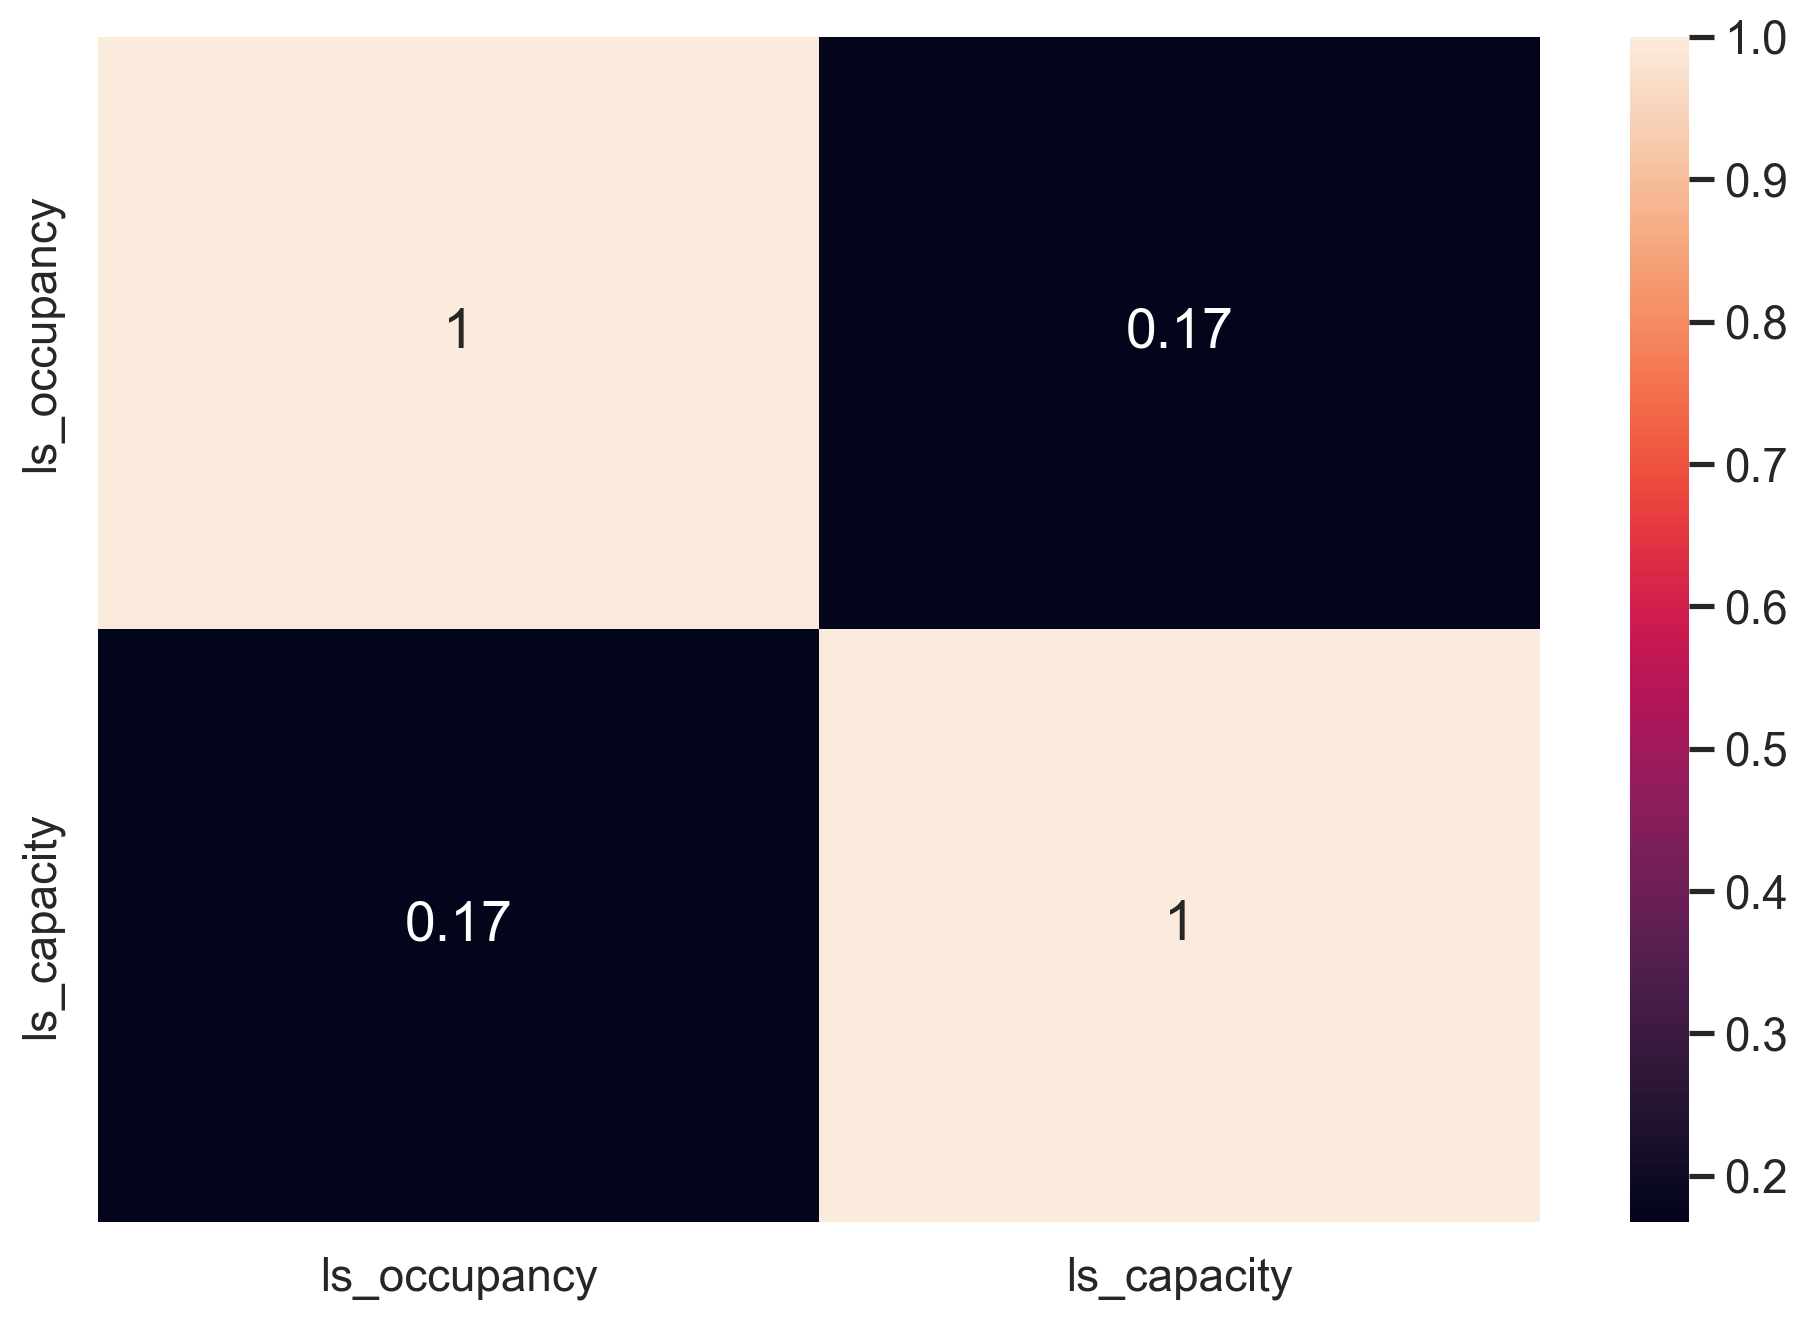

In [118]:
from scipy.stats import pearsonr

sns.heatmap(union[["ls_occupancy", "ls_capacity"]].corr(), annot=True)
q = union[["ls_occupancy", "ls_capacity"]].dropna().drop_duplicates()
pearsonr(q["ls_occupancy"], q["ls_capacity"])

In [119]:
dff = fad.groupby(["Date", "farm_name", "PhysiologicalGroupName", "ingredient_group"])["PhysicalWeight_kg"].mean().reset_index()

dff = dff[dff["PhysiologicalGroupName"].isin(["С1", "С2"])]